# Testando um modelo simples de aprendizado de um Datase aleatório

## Imports

In [1]:
import IPython.display as ipd
import json
import numpy as np
import matplotlib.pyplot as plt
import random
import soundfile as sf
import pandas as pd

from fm_synth import FMSynth, SAMPLE_RATE


## Gerando um dataset aleatório

### Rodando aleatoriamente e salvando o resultado

In [2]:
duracao_amostras = 1
tamanho_dataset = 20000
precisao_decimal = 3

## Lendo o dataset no formato pandas

### Lendo as variáveis de entrada

In [3]:
samples = []
for i in range(tamanho_dataset):
    signal = sf.read(f"dataset_big/sample_{i}.wav")
    samples.append(signal)

samples = pd.DataFrame(samples)

In [4]:
samples = samples.drop(columns=[1])
samples.head()

,0
0,"[0.0, 0.00067138671875, 0.00054931640625, -6.1..."
1,"[0.0, 6.103515625e-05, 0.000244140625, 0.00027..."
2,"[0.0, 6.103515625e-05, 0.000213623046875, 0.00..."
3,"[0.0, 6.103515625e-05, 0.000244140625, 0.00024..."
4,"[0.0, 0.0, 0.0, -3.0517578125e-05, -6.10351562..."


### Lendo o alvo

In [5]:
with open("dataset_big/parameters.json", "r") as f:
    target = f.read()

target = json.loads(target)
target = target[:tamanho_dataset]

target = pd.DataFrame(target)
target.head()

,id,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,0,3769.154,0.223,0.898,0.210,0.857,0.767,0.714,0.251,0.204,...,0.832,0.707,0.817,0.999,0.870,0.852,0.055,0.063,0.478,0.013
1,1,2417.237,0.888,0.089,0.048,0.168,0.166,0.580,0.057,0.780,...,0.626,0.208,0.834,0.263,0.471,0.352,0.124,0.017,0.423,0.021
2,2,2441.183,0.180,0.768,0.069,0.511,0.653,0.064,0.932,0.588,...,0.420,0.803,0.266,0.410,0.444,0.234,0.094,0.030,0.050,0.050
3,3,2655.831,0.752,0.622,0.686,0.462,0.642,0.305,0.059,0.452,...,0.779,0.541,0.431,0.045,0.728,0.437,0.162,0.094,0.158,0.087
4,4,3788.123,0.299,0.768,0.510,0.301,0.397,0.623,0.111,0.192,...,0.325,0.439,0.971,0.030,0.994,0.048,0.199,0.051,0.121,0.171


In [6]:
target = target.drop(columns=["id"])
target.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,3769.154,0.223,0.898,0.210,0.857,0.767,0.714,0.251,0.204,0.853,...,0.832,0.707,0.817,0.999,0.870,0.852,0.055,0.063,0.478,0.013
1,2417.237,0.888,0.089,0.048,0.168,0.166,0.580,0.057,0.780,0.078,...,0.626,0.208,0.834,0.263,0.471,0.352,0.124,0.017,0.423,0.021
2,2441.183,0.180,0.768,0.069,0.511,0.653,0.064,0.932,0.588,0.934,...,0.420,0.803,0.266,0.410,0.444,0.234,0.094,0.030,0.050,0.050
3,2655.831,0.752,0.622,0.686,0.462,0.642,0.305,0.059,0.452,0.722,...,0.779,0.541,0.431,0.045,0.728,0.437,0.162,0.094,0.158,0.087
4,3788.123,0.299,0.768,0.510,0.301,0.397,0.623,0.111,0.192,0.880,...,0.325,0.439,0.971,0.030,0.994,0.048,0.199,0.051,0.121,0.171


### Juntando alvo e features

In [7]:
ds = pd.concat([samples, target], axis=1)
ds.head()

,0,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,"[0.0, 0.00067138671875, 0.00054931640625, -6.1...",3769.154,0.223,0.898,0.210,0.857,0.767,0.714,0.251,0.204,...,0.832,0.707,0.817,0.999,0.870,0.852,0.055,0.063,0.478,0.013
1,"[0.0, 6.103515625e-05, 0.000244140625, 0.00027...",2417.237,0.888,0.089,0.048,0.168,0.166,0.580,0.057,0.780,...,0.626,0.208,0.834,0.263,0.471,0.352,0.124,0.017,0.423,0.021
2,"[0.0, 6.103515625e-05, 0.000213623046875, 0.00...",2441.183,0.180,0.768,0.069,0.511,0.653,0.064,0.932,0.588,...,0.420,0.803,0.266,0.410,0.444,0.234,0.094,0.030,0.050,0.050
3,"[0.0, 6.103515625e-05, 0.000244140625, 0.00024...",2655.831,0.752,0.622,0.686,0.462,0.642,0.305,0.059,0.452,...,0.779,0.541,0.431,0.045,0.728,0.437,0.162,0.094,0.158,0.087
4,"[0.0, 0.0, 0.0, -3.0517578125e-05, -6.10351562...",3788.123,0.299,0.768,0.510,0.301,0.397,0.623,0.111,0.192,...,0.325,0.439,0.971,0.030,0.994,0.048,0.199,0.051,0.121,0.171


In [8]:
ds.shape

(20000, 22)

## Separando treino e teste

In [9]:
train = ds.sample(frac=0.75, random_state=0)
test = ds.drop(train.index)

In [10]:
train.head(5)

,0,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
19134,"[0.0, 0.0001220703125, 0.000396728515625, 0.00...",2607.881,0.219,0.754,0.045,0.106,0.343,0.364,0.238,0.759,...,0.186,0.453,0.588,0.446,0.273,0.819,0.180,0.084,0.328,0.067
4981,"[0.0, 0.002410888671875, 0.006317138671875, 0....",2818.949,0.510,0.102,0.243,0.210,0.692,0.221,0.487,0.940,...,0.778,0.379,0.171,0.522,0.815,0.211,0.003,0.002,0.329,0.198
16643,"[0.0, 0.000274658203125, 0.000762939453125, 0....",2549.904,0.217,0.035,0.732,0.545,0.712,0.832,0.711,0.267,...,0.473,0.772,0.845,0.940,0.239,0.294,0.034,0.079,0.139,0.085
19117,"[0.0, 0.0, 3.0517578125e-05, -3.0517578125e-05...",3845.764,0.348,0.865,0.405,0.046,0.870,0.102,0.975,0.718,...,0.725,0.828,0.200,0.656,0.108,0.074,0.172,0.080,0.269,0.168
5306,"[0.0, 0.0, 3.0517578125e-05, 3.0517578125e-05,...",2618.959,0.902,0.907,0.536,0.054,0.540,0.242,0.468,0.109,...,0.614,0.059,0.767,0.981,0.486,0.083,0.175,0.015,0.229,0.006


In [11]:
x = pd.DataFrame(train[0])
x.head()

,0
19134,"[0.0, 0.0001220703125, 0.000396728515625, 0.00..."
4981,"[0.0, 0.002410888671875, 0.006317138671875, 0...."
16643,"[0.0, 0.000274658203125, 0.000762939453125, 0...."
19117,"[0.0, 0.0, 3.0517578125e-05, -3.0517578125e-05..."
5306,"[0.0, 0.0, 3.0517578125e-05, 3.0517578125e-05,..."


In [12]:
x = np.array(x[0].values.tolist())
x[0]

array([ 0.00000000e+00,  1.22070312e-04,  3.96728516e-04, ...,
       -9.15527344e-05, -3.05175781e-04, -1.83105469e-04])

In [13]:
len(x[0])

22050

In [14]:
y = train.drop(columns=[0])
y.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
19134,2607.881,0.219,0.754,0.045,0.106,0.343,0.364,0.238,0.759,0.747,...,0.186,0.453,0.588,0.446,0.273,0.819,0.180,0.084,0.328,0.067
4981,2818.949,0.510,0.102,0.243,0.210,0.692,0.221,0.487,0.940,0.161,...,0.778,0.379,0.171,0.522,0.815,0.211,0.003,0.002,0.329,0.198
16643,2549.904,0.217,0.035,0.732,0.545,0.712,0.832,0.711,0.267,0.605,...,0.473,0.772,0.845,0.940,0.239,0.294,0.034,0.079,0.139,0.085
19117,3845.764,0.348,0.865,0.405,0.046,0.870,0.102,0.975,0.718,0.048,...,0.725,0.828,0.200,0.656,0.108,0.074,0.172,0.080,0.269,0.168
5306,2618.959,0.902,0.907,0.536,0.054,0.540,0.242,0.468,0.109,0.385,...,0.614,0.059,0.767,0.981,0.486,0.083,0.175,0.015,0.229,0.006


In [15]:
from sklearn.preprocessing import StandardScaler
scaler_y = StandardScaler()
y_train_norm = scaler_y.fit_transform(y)
print(y_train_norm)

[[-0.67284942 -0.98177363  0.89188411 ...  1.14661065  0.52649214
  -0.59420916]
 [-0.30937711  0.02966779 -1.37672539 ... -1.71010907  0.53342681
   1.68114106]
 [-0.77268944 -0.98872512 -1.60984937 ...  0.97242043 -0.78415928
  -0.28156562]
 ...
 [-0.19287958 -0.1684496  -0.15195462 ... -0.03788289  1.6776463
   0.62162684]
 [-0.9267951   0.64835017  1.55646143 ... -0.21207312  0.31845224
   1.35112843]
 [-0.78036468  0.8012829   1.18763841 ...  1.5646672   1.31704379
   1.45534295]]


### Redimensionando a entrada

In [16]:
print(x.shape)
x = x.reshape((x.shape[0], x.shape[1], 1))
print(x.shape)

print(x[0])

# frame_length = 2048

# dataset = []
# for sample in x:
#   length = sample.shape[0]
#   num_frames = int(length / frame_length)
#   amostras_uteis = num_frames * frame_length
#   sample_cutted = sample[:amostras_uteis]
#   sample_cutted = sample_cutted.reshape(num_frames, frame_length)
#   dataset.append(sample_cutted)

# x = np.array(dataset)
# print(x.shape)
# x[0:5]

(15000, 22050)
(15000, 22050, 1)
[[ 0.00000000e+00]
 [ 1.22070312e-04]
 [ 3.96728516e-04]
 ...
 [-9.15527344e-05]
 [-3.05175781e-04]
 [-1.83105469e-04]]


## Construindo o modelo

In [17]:
from keras.layers import TimeDistributed, Dense, Input, Lambda, BatchNormalization, Concatenate, Conv1D, ZeroPadding1D, Flatten, Dropout, MaxPooling1D
from keras.models import Model
from tensorflow.keras.utils import plot_model
from keras.callbacks import EarlyStopping
import tensorflow as tf

2025-08-24 20:52:36.759027: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-24 20:52:37.075775: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756079557.188503    5218 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756079557.217478    5218 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756079557.495440    5218 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [18]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [19]:
# Configurando para não alocar diretamente toda a memória da GPU (alocar conforme necessário)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Aloca memória conforme necessário
    except RuntimeError as e:
        print(e)

I0000 00:00:1756079559.964916    5218 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2795 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/sergio/@pessoal/fmsynth/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


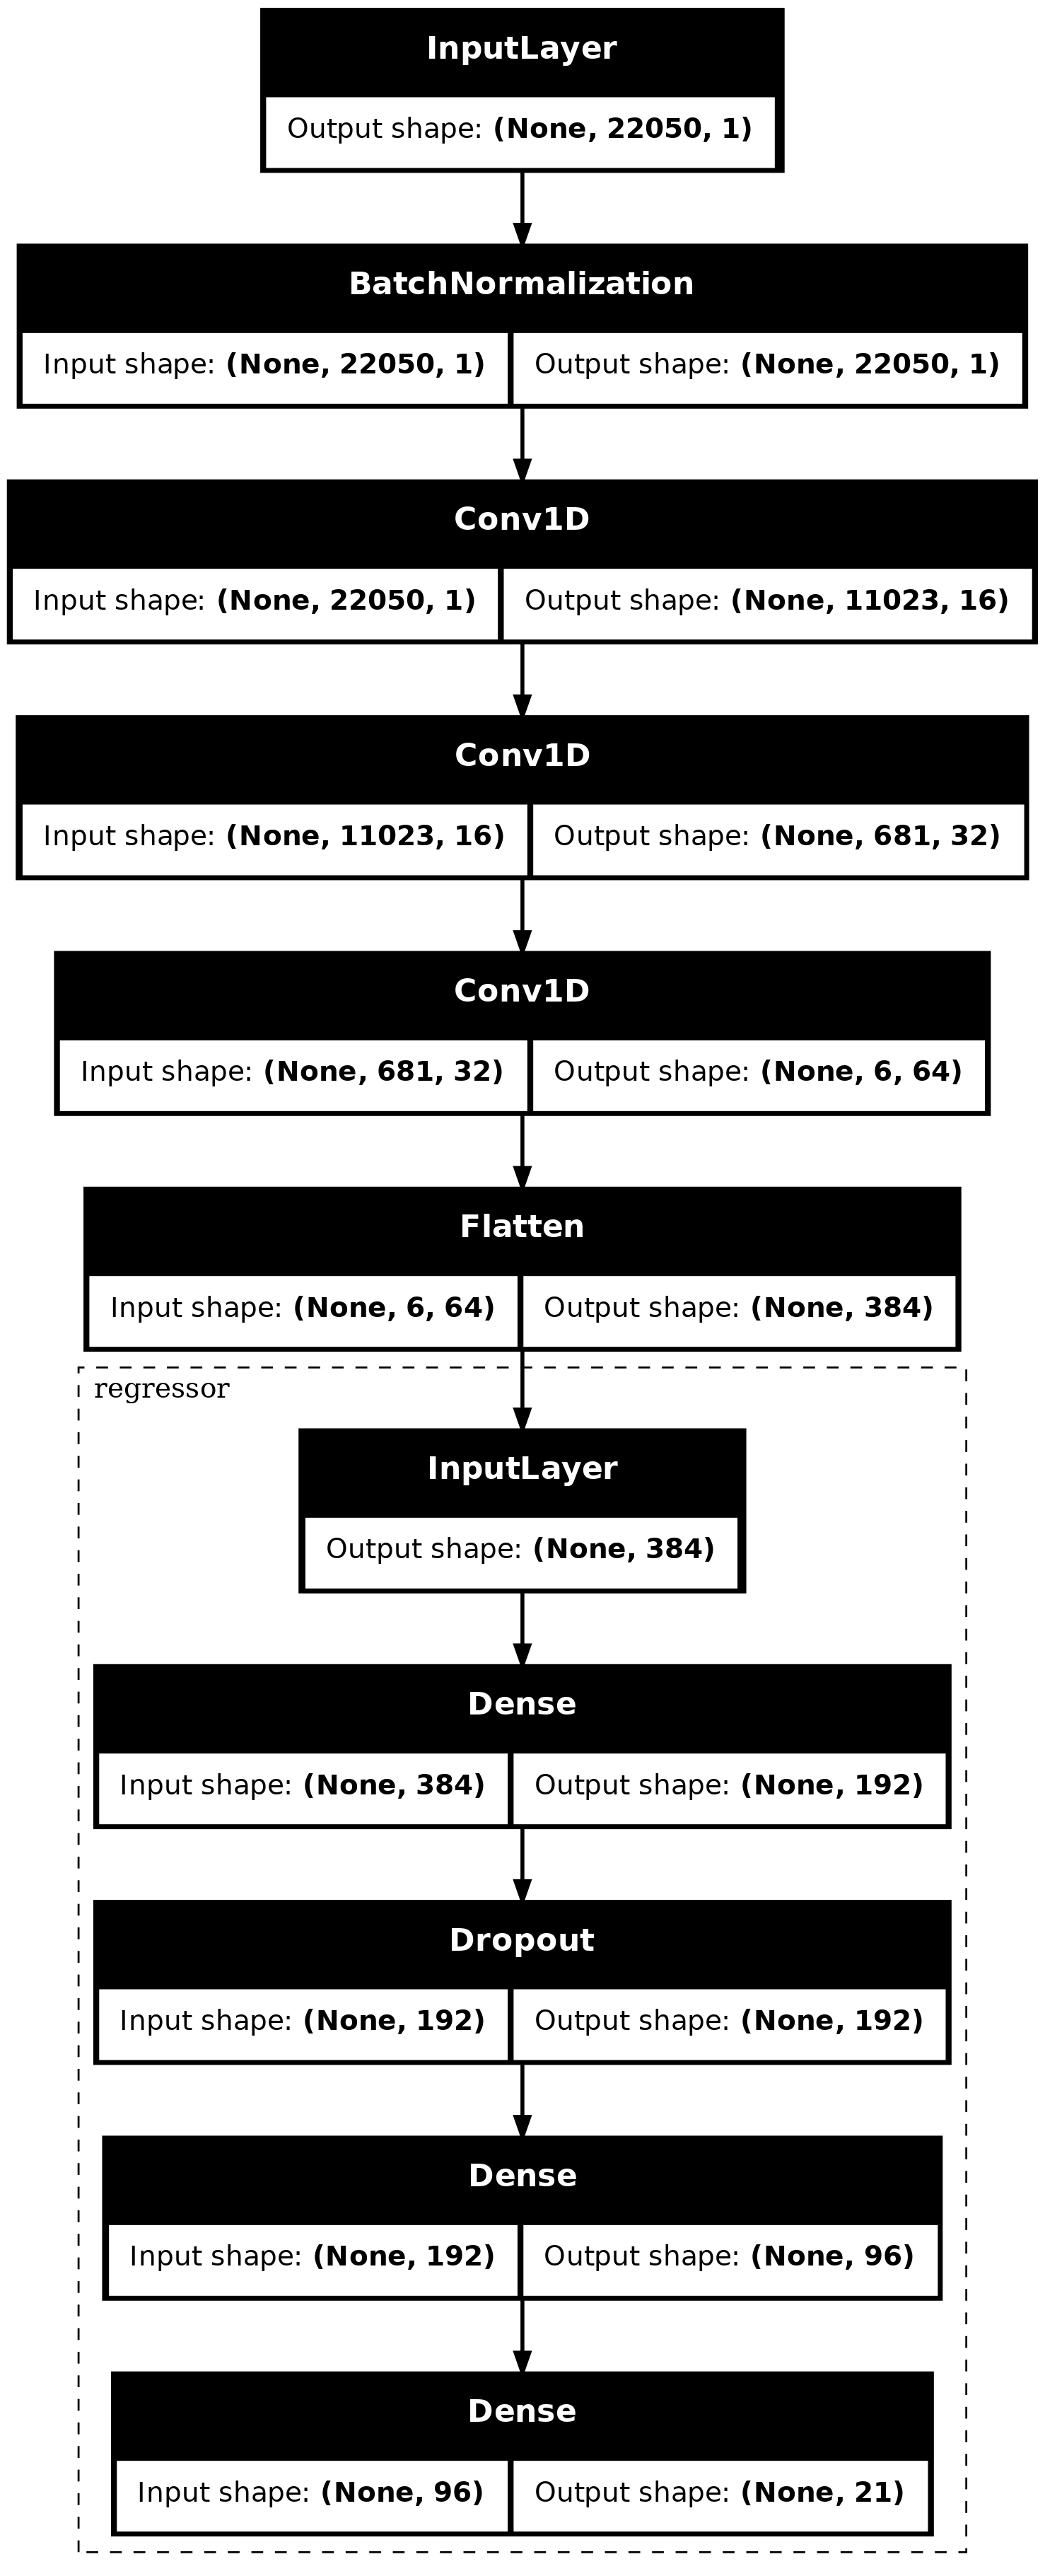

In [20]:
def regressor(input_dims, output_dims, activation, bias):
  input_layer = Input(shape=[input_dims])

  x_0 = Dense(int(input_dims/2), activation=activation, use_bias=bias, kernel_regularizer="l2")(input_layer)
  x_0 = Dropout(0.2)(x_0)
  x_2 = Dense(int(input_dims/4), activation=activation, use_bias=bias)(x_0)
  saidas = Dense(output_dims, activation=None, name='regressor_saidas', use_bias=bias)(x_2)

  return Model(input_layer, saidas, name="regressor")

def build_models(input_len, input_dims, output_dims, activation, bias):
  
  # Camadas de entrada
  input_layer = Input(shape=(input_len, input_dims))

  x_n = BatchNormalization()(input_layer)

  # Features 1
  extrator1 = Conv1D(
    filters=16,
    kernel_size=5,
    strides=2,
    activation='relu',
    input_shape=(input_len, 1),
    kernel_regularizer="l2",
    use_bias=True,
  )
  # pooling1 = MaxPooling1D(pool_size=16)

  features1 = extrator1(x_n)
  # features1 = pooling1(features1)

  extrator1_2 = Conv1D(
    filters=32,
    kernel_size=128,
    strides=16,
    activation='relu',
    input_shape=(input_len, 1),
    kernel_regularizer="l2",
    use_bias=True,
  )
  # pooling1_2 = MaxPooling1D(pool_size=4)

  features1_2 = extrator1_2(features1)
  # features1_2 = pooling1_2(features1_2)

  extrator1_3 = Conv1D(
    filters=64,
    kernel_size=512,
    strides=32,
    activation='relu',
    input_shape=(input_len, 1),
    kernel_regularizer="l2",
    use_bias=True,
  )
  # pooling1_2 = MaxPooling1D(pool_size=4)

  features1_3 = extrator1_3(features1_2)
  # features1_2 = pooling1_2(features1_2)

  features1_flatten1 = Flatten()(features1_3)

  # Regrssão
  regressao = regressor(features1_flatten1.shape[1], output_dims, activation, bias)

  saida = regressao(features1_flatten1)
  
  return (
      Model(input_layer, saida, name="regressao"),
      Model(input_layer, features1_flatten1, name="projecao")
  )

model, features = build_models(x.shape[1], x.shape[2], y_train_norm.shape[1], 'relu', False)
# model, features = build_models(x.shape[1], x.shape[2], y.shape[1], 'relu', False)
model.compile(optimizer='adamax', loss='mse', metrics=['mae', 'mse', 'mean_absolute_percentage_error'])
plot_model(model, show_shapes=True, expand_nested=True)

In [21]:
# Callback para recuperar o melhor peso, e parar quando ficar três épocas sem melhora
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

# Treinando o modelo
history = model.fit(x, y_train_norm, epochs=15, validation_split = 0.2, callbacks=[callback])

Epoch 1/15


I0000 00:00:1756079564.573282    5692 service.cc:152] XLA service 0x7fb9fc0205b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756079564.574241    5692 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-08-24 20:52:44.667575: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1756079564.861612    5692 cuda_dnn.cc:529] Loaded cuDNN version 90300


 10/375 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 4.0670 - mae: 0.8765 - mean_absolute_percentage_error: 139.5043 - mse: 1.0301

I0000 00:00:1756079569.270230    5692 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 1.4779 - mae: 0.8187 - mean_absolute_percentage_error: 129.2131 - mse: 0.9262 - val_loss: 1.0324 - val_mae: 0.8002 - val_mean_absolute_percentage_error: 120.5065 - val_mse: 0.8931
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.9252 - mae: 0.7553 - mean_absolute_percentage_error: 147.0257 - mse: 0.8339 - val_loss: 0.8561 - val_mae: 0.7201 - val_mean_absolute_percentage_error: 130.4700 - val_mse: 0.7947
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.8476 - mae: 0.7286 - mean_absolute_percentage_error: 143.5687 - mse: 0.7995 - val_loss: 0.8215 - val_mae: 0.7130 - val_mean_absolute_percentage_error: 122.7749 - val_mse: 0.7822
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.8234 - mae: 0.7203 - mean_absolute_percentage_error: 130.6731 - mse: 0.7877 - val_loss: 0.8086 - val_mae: 0.7074 - val_mean_absolute_percentage_error: 119.3939 - val_mse: 0.7746
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19m

In [22]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mean_absolute_percentage_error,mse,val_loss,val_mae,val_mean_absolute_percentage_error,val_mse,epoch
10,0.775791,0.688718,114.456093,0.749399,0.772130,0.680899,104.839958,0.746182,10
11,0.774750,0.688603,137.691345,0.749079,0.777010,0.691194,120.636269,0.751834,11
12,0.772653,0.687395,117.242271,0.747796,0.766024,0.676641,105.120804,0.741543,12
13,0.772360,0.687979,127.343178,0.748155,0.766806,0.678902,106.258667,0.742994,13
14,0.769662,0.685542,125.608009,0.746037,0.760824,0.670510,109.230972,0.737563,14


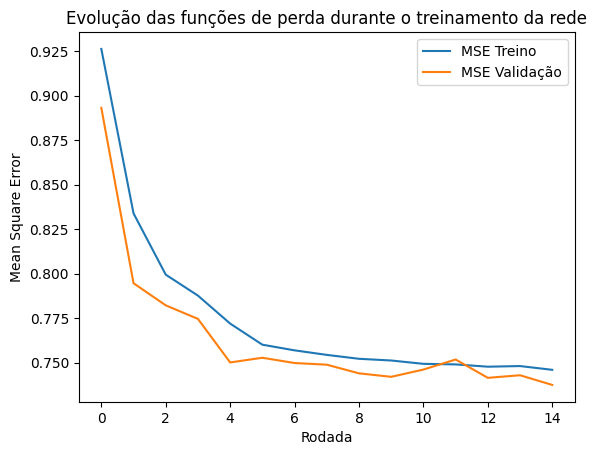

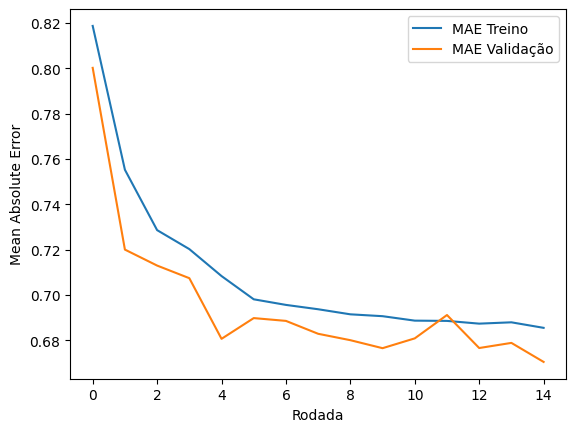

In [23]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure()
plt.title("Evolução das funções de perda durante o treinamento da rede")
plt.xlabel('Rodada')
plt.ylabel('Mean Square Error')
plt.plot(hist['epoch'], hist['mse'], label='MSE Treino')
plt.plot(hist['epoch'], hist['val_mse'], label = 'MSE Validação')
plt.legend()

plt.figure()
plt.xlabel('Rodada')
plt.ylabel('Mean Absolute Error')
plt.plot(hist['epoch'], hist['mae'], label='MAE Treino')
plt.plot(hist['epoch'], hist['val_mae'], label = 'MAE Validação')
plt.legend()

plt.show()

## Prevendo a amostra de teste

### Ajustando a base de teste

In [24]:
x_t = pd.DataFrame(test[0])
x_t.head()

,0
4,"[0.0, 0.0, 0.0, -3.0517578125e-05, -6.10351562..."
10,"[0.0, 0.000274658203125, 0.000732421875, 0.000..."
11,"[0.0, 0.000396728515625, 0.000579833984375, -0..."
13,"[0.0, 0.001495361328125, 0.003662109375, 0.002..."
17,"[0.0, 0.000244140625, 0.00067138671875, 0.0007..."


In [25]:
x_t = np.array(x_t[0].values.tolist())
x_t[0]

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        0.00000000e+00, -3.05175781e-05,  0.00000000e+00])

In [26]:
len(x_t[0])

22050

In [27]:
y_t = test.drop(columns=[0])
y_t.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
4,3788.123,0.299,0.768,0.510,0.301,0.397,0.623,0.111,0.192,0.880,...,0.325,0.439,0.971,0.030,0.994,0.048,0.199,0.051,0.121,0.171
10,2408.471,0.256,0.058,0.496,0.935,0.082,0.885,0.337,0.264,0.335,...,0.983,0.357,0.935,0.612,0.350,0.999,0.120,0.028,0.070,0.144
11,3956.830,0.270,0.251,0.398,0.639,0.835,0.512,0.998,0.690,0.150,...,0.359,0.765,0.484,0.125,0.459,0.703,0.073,0.003,0.341,0.044
13,3119.113,0.477,0.451,0.781,0.454,0.613,0.102,0.119,0.269,0.385,...,0.648,0.993,0.338,0.752,0.117,0.835,0.020,0.076,0.494,0.102
17,2031.225,0.468,0.849,0.317,0.871,0.381,0.535,0.968,0.017,0.950,...,0.110,0.205,0.698,0.809,0.924,0.763,0.100,0.024,0.334,0.085


### Chamando o modelo para predição

In [28]:
y_pred_norm = model.predict(x_t)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


In [29]:
y_pred = scaler_y.inverse_transform(y_pred_norm)

In [30]:
y_pred = pd.DataFrame(y_pred)
y_pred.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,3320.820312,0.484612,0.517637,0.496047,0.494149,0.480847,0.505435,0.497469,0.477561,0.485626,...,0.494959,0.514623,0.470632,0.481082,0.506356,0.043775,0.171914,0.070097,0.163300,0.137421
1,2333.011719,0.519129,0.504741,0.476734,0.474396,0.503922,0.517456,0.511750,0.473487,0.491317,...,0.520285,0.519079,0.472097,0.495920,0.484072,0.925507,0.114626,0.033139,0.067132,0.144087
2,3851.654053,0.485199,0.478669,0.487358,0.524744,0.497007,0.514253,0.515342,0.498611,0.510270,...,0.503835,0.480119,0.489256,0.494189,0.490531,0.709890,0.072907,0.020519,0.331817,0.045793
3,3127.192139,0.493257,0.483919,0.487672,0.509360,0.494479,0.505556,0.505010,0.463710,0.493586,...,0.511932,0.504070,0.475129,0.485818,0.504797,0.840796,0.018199,0.071136,0.431232,0.099578
4,2080.605469,0.484458,0.505966,0.479910,0.503524,0.458447,0.512136,0.505790,0.489945,0.491175,...,0.506434,0.517447,0.491191,0.485956,0.477906,0.698914,0.103463,0.022703,0.286530,0.085174


### Calculando erro de teste

In [31]:
mse = tf.keras.losses.MSE(y_t, y_pred).numpy().mean()
mae = tf.keras.losses.MAE(y_t, y_pred).numpy().mean()
rmse = np.sqrt(mse)

In [32]:
print(f"RMSE Test: {rmse}")
print(f"MSE Test: {mse}")
print(f"MAE Test: {mae}")

RMSE Test: 31.662614822387695
MSE Test: 1002.5211791992188
MAE Test: 4.678521156311035
